# GWHD 2021: Score Tertiles vs Domain Pattern

This notebook splits the image difficulty scores into low 30%, mid 30%, and top 30% groups, then checks:

- which domains dominate each tertile,
- whether the top-score tertile is concentrated in a minority domain,
- what is special about that domain in terms of object size and density,
- whether the model is already weak on the corresponding object-size buckets.

The analysis uses the score file from `seed_123` and the baseline model metrics from the same run.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

BASE_DIR = Path('/home/khanh/Projects/DifficultyAgri')
SCORE_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_3_Scoring_Dataset/score_results.json'
EVAL_PATH = BASE_DIR / 'results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_2_Train_and_Evaluate_BASELINE_MODEL/evaluation_baseline_on_original_test.json'
TRAIN_CSV = BASE_DIR / 'datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv'

for path in [SCORE_PATH, EVAL_PATH, TRAIN_CSV]:
    print(path, 'exists =', path.exists())

with open(EVAL_PATH, 'r', encoding='utf-8') as f:
    eval_data = json.load(f)

with open(SCORE_PATH, 'r', encoding='utf-8') as f:
    score_data = json.load(f)

train_df = pd.read_csv(TRAIN_CSV)

print('Training rows:', len(train_df))
print('Train columns:', train_df.columns.tolist())
print('Score images:', len(score_data.get('image_difficulties', [])))
print('Baseline AP:', eval_data.get('COCO_AP'))
print('AP_small:', eval_data.get('AP_small'), 'AP_very_small:', eval_data.get('AP_very_small'))

/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_3_Scoring_Dataset/score_results.json exists = True
/home/khanh/Projects/DifficultyAgri/results/055_multiseed_copy_paste_exp_gwhd_2021/seed_123/Step_2_Train_and_Evaluate_BASELINE_MODEL/evaluation_baseline_on_original_test.json exists = True
/home/khanh/Projects/DifficultyAgri/datasets/global_wheat_head/raw_v2/gwhd_2021/competition_train.csv exists = True
Training rows: 3657
Train columns: ['image_name', 'BoxesString', 'domain']
Score images: 3655
Baseline AP: 0.23071767984742816
AP_small: 0.06474143286407855 AP_very_small: 0.00702389430211487


Score tertile thresholds:
  low/mid cut  = 0.2681
  mid/top cut  = 0.3662

               n_images  mean_score  median_score  mean_num_objects  mean_fp_rate  mean_miss_rate
score_tertile                                                                                    
low_30             1097      0.2204        0.2297           46.6472        0.0384          0.0206
mid_30             1461      0.3143        0.3123           48.9103        0.0737          0.0554
top_30             1097      0.4554        0.4202           37.3938        0.1637          0.1365
Domain share by tertile (rows sum to 1):
domain         Arvalis_1  Arvalis_10  Arvalis_11  Arvalis_12  Arvalis_2  Arvalis_3  Arvalis_4  Arvalis_5  Arvalis_6  Arvalis_7  Arvalis_8  Arvalis_9  ETHZ_1  Inrae_1  NMBU_1  NMBU_2  Rres_1  ULiège-GxABT_1
score_tertile                                                                                                                                                                               

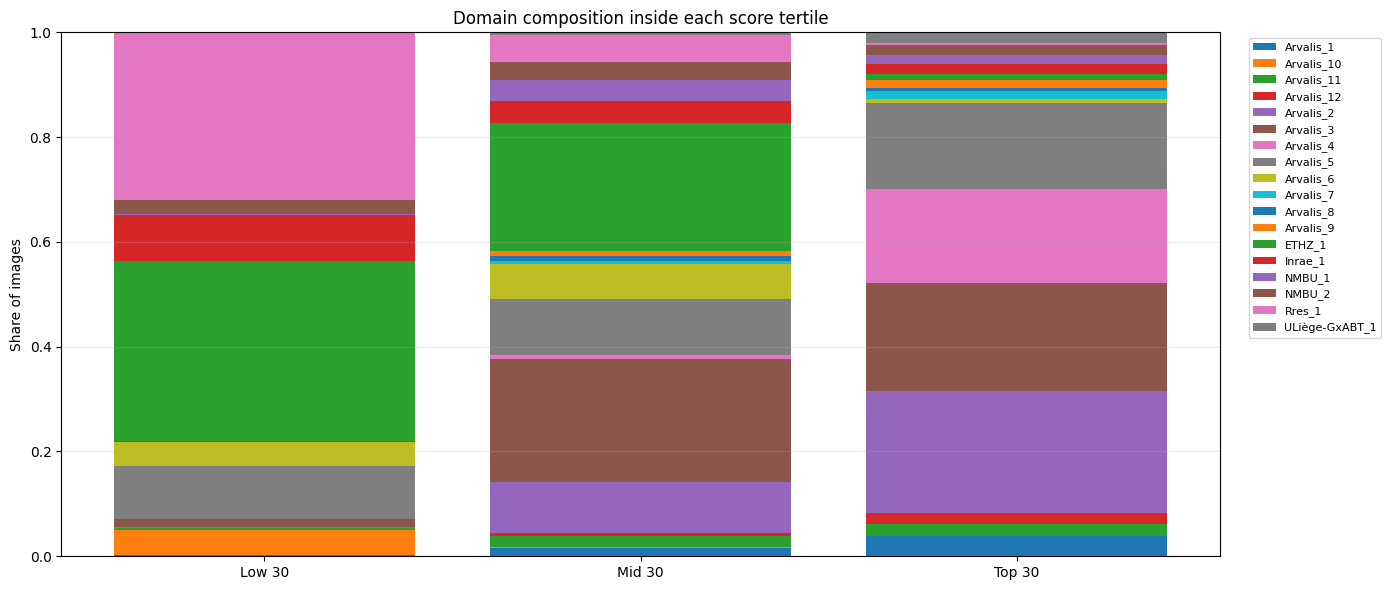

In [2]:
# Build image-level score table and split it into tertiles.
score_rows = []
for item in score_data.get('image_difficulties', []):
    image_path = item.get('image_path', '')
    if not image_path:
        continue
    score_rows.append({
        'image_name': Path(image_path).name,
        'difficulty_score': float(item.get('difficulty_score', np.nan)),
        'num_objects': float(item.get('num_objects', np.nan)),
        'false_positive_rate': float(item.get('false_positive_rate', np.nan)),
        'missed_detections_rate': float(item.get('missed_detections_rate', np.nan)),
    })

score_df = pd.DataFrame(score_rows).dropna(subset=['image_name', 'difficulty_score'])
filename_to_domain = dict(zip(train_df['image_name'], train_df['domain']))
score_df['domain'] = score_df['image_name'].map(filename_to_domain)
score_df = score_df.dropna(subset=['domain']).copy()

q30 = score_df['difficulty_score'].quantile(0.30)
q70 = score_df['difficulty_score'].quantile(0.70)

def tertile_label(score: float) -> str:
    if score >= q70:
        return 'top_30'
    if score <= q30:
        return 'low_30'
    return 'mid_30'

score_df['score_tertile'] = score_df['difficulty_score'].apply(tertile_label)
score_df['score_tertile'] = pd.Categorical(score_df['score_tertile'], categories=['low_30', 'mid_30', 'top_30'], ordered=True)

print('Score tertile thresholds:')
print('  low/mid cut  =', round(q30, 4))
print('  mid/top cut  =', round(q70, 4))
print()
print(score_df.groupby('score_tertile').agg(
    n_images=('image_name', 'count'),
    mean_score=('difficulty_score', 'mean'),
    median_score=('difficulty_score', 'median'),
    mean_num_objects=('num_objects', 'mean'),
    mean_fp_rate=('false_positive_rate', 'mean'),
    mean_miss_rate=('missed_detections_rate', 'mean'),
).round(4).to_string())

# Domain share by tertile.
domain_tertile_counts = (
    score_df.groupby(['score_tertile', 'domain'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=['low_30', 'mid_30', 'top_30'], fill_value=0)
)
domain_tertile_share = domain_tertile_counts.div(domain_tertile_counts.sum(axis=1), axis=0).fillna(0)

print('Domain share by tertile (rows sum to 1):')
print(domain_tertile_share.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(domain_tertile_share))
x = np.arange(len(domain_tertile_share.index))
for domain in domain_tertile_share.columns:
    vals = domain_tertile_share[domain].values
    ax.bar(x, vals, bottom=bottom, label=domain)
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(['Low 30', 'Mid 30', 'Top 30'])
ax.set_ylabel('Share of images')
ax.set_title('Domain composition inside each score tertile')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Object characteristics by score tertile:
               n_images  mean_score  mean_objects  median_objects  mean_object_area  mean_equiv_side  pct_very_small  pct_small  pct_medium  pct_large
score_tertile                                                                                                                                         
low_30             1064      0.2272       48.0940            50.0         6991.6240          79.0086          0.0160     0.3590     79.5847    20.0403
mid_30             1461      0.3143       48.9103            49.0         7224.6250          79.1175          0.0979     0.9819     77.3803    21.5399
top_30             1080      0.4515       37.9824            37.0         6789.8294          76.8421          0.0957     1.2389     79.4649    19.2006

Top domains in low_30:
   domain  n_images  share_in_tertile  mean_score  mean_objects  mean_object_area  pct_very_small  pct_small  pct_medium  pct_large
   ETHZ_1       377            0.3543      0.235

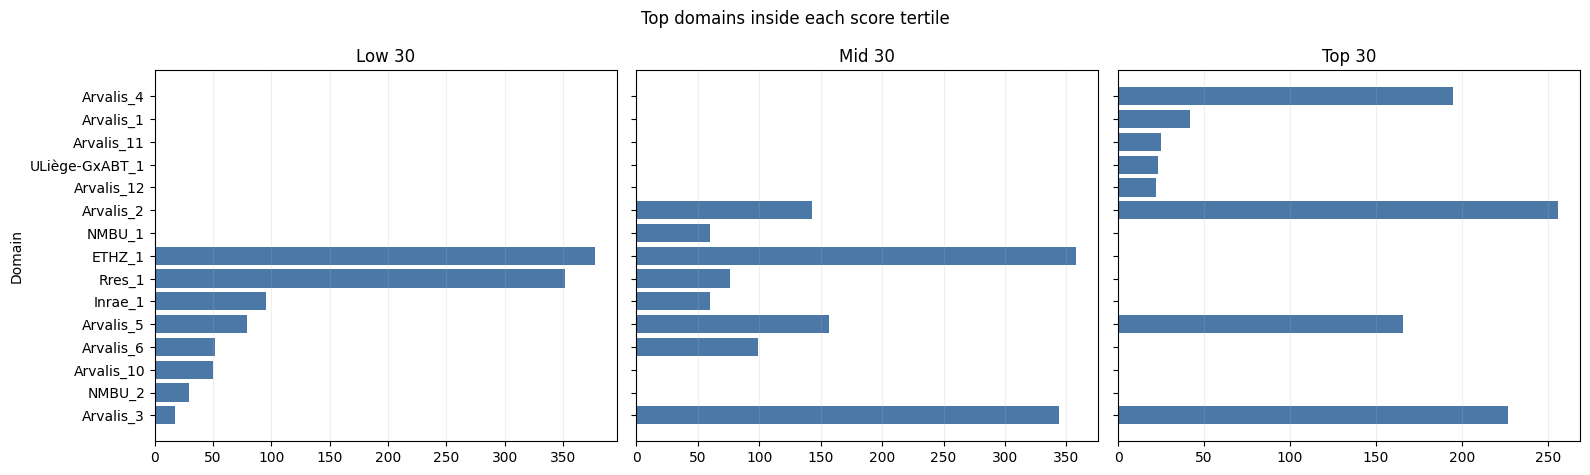

In [3]:
# Parse BoxesString to get object density and size proxies.
def parse_boxes_string(boxes_string):
    if not isinstance(boxes_string, str) or not boxes_string.strip():
        return []
    boxes = []
    for chunk in boxes_string.split(';'):
        chunk = chunk.strip()
        if not chunk:
            continue
        parts = chunk.split()
        if len(parts) < 4:
            continue
        x1, y1, x2, y2 = map(float, parts[:4])
        width = max(0.0, x2 - x1)
        height = max(0.0, y2 - y1)
        area_px = width * height
        equiv_side = math.sqrt(area_px) if area_px > 0 else 0.0
        boxes.append({'area_px': area_px, 'equiv_side': equiv_side})
    return boxes

def size_bucket(side_px):
    if side_px < 20:
        return 'very_small'
    if side_px < 32:
        return 'small'
    if side_px < 96:
        return 'medium'
    return 'large'

object_rows = []
for row in train_df.itertuples(index=False):
    boxes = parse_boxes_string(getattr(row, 'BoxesString'))
    for box in boxes:
        object_rows.append({
            'image_name': getattr(row, 'image_name'),
            'domain': getattr(row, 'domain'),
            'area_px': box['area_px'],
            'equiv_side': box['equiv_side'],
            'size_bucket': size_bucket(box['equiv_side']),
        })

object_df = pd.DataFrame(object_rows)
object_df['size_bucket'] = pd.Categorical(object_df['size_bucket'], categories=['very_small', 'small', 'medium', 'large'], ordered=True)

image_object_stats = (
    object_df.groupby(['image_name', 'domain'])
    .agg(
        n_objects=('area_px', 'size'),
        mean_object_area=('area_px', 'mean'),
        mean_equiv_side=('equiv_side', 'mean'),
        pct_very_small=('size_bucket', lambda s: 100 * (s == 'very_small').mean()),
        pct_small=('size_bucket', lambda s: 100 * (s == 'small').mean()),
        pct_medium=('size_bucket', lambda s: 100 * (s == 'medium').mean()),
        pct_large=('size_bucket', lambda s: 100 * (s == 'large').mean()),
    )
    .reset_index()
)

image_model_df = score_df.merge(image_object_stats, on=['image_name', 'domain'], how='inner')

# Bucket-level summary by tertile.
tertile_object_summary = image_model_df.groupby('score_tertile').agg(
    n_images=('image_name', 'count'),
    mean_score=('difficulty_score', 'mean'),
    mean_objects=('n_objects', 'mean'),
    median_objects=('n_objects', 'median'),
    mean_object_area=('mean_object_area', 'mean'),
    mean_equiv_side=('mean_equiv_side', 'mean'),
    pct_very_small=('pct_very_small', 'mean'),
    pct_small=('pct_small', 'mean'),
    pct_medium=('pct_medium', 'mean'),
    pct_large=('pct_large', 'mean'),
).round(4)

print('Object characteristics by score tertile:')
print(tertile_object_summary.to_string())

# Per-tertile dominant domains and what is special about them.
tert_domain_table = (
    image_model_df.groupby(['score_tertile', 'domain'])
    .agg(
        n_images=('image_name', 'count'),
        mean_score=('difficulty_score', 'mean'),
        mean_objects=('n_objects', 'mean'),
        mean_object_area=('mean_object_area', 'mean'),
        pct_very_small=('pct_very_small', 'mean'),
        pct_small=('pct_small', 'mean'),
        pct_medium=('pct_medium', 'mean'),
        pct_large=('pct_large', 'mean'),
    )
    .reset_index()
    .sort_values(['score_tertile', 'n_images'], ascending=[True, False])
)

for tertile in ['low_30', 'mid_30', 'top_30']:
    block = tert_domain_table[tert_domain_table['score_tertile'] == tertile].copy()
    block['share_in_tertile'] = block['n_images'] / block['n_images'].sum()
    print(f'\nTop domains in {tertile}:')
    print(block[['domain', 'n_images', 'share_in_tertile', 'mean_score', 'mean_objects', 'mean_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large']].head(5).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, tertile in zip(axes, ['low_30', 'mid_30', 'top_30']):
    block = tert_domain_table[tert_domain_table['score_tertile'] == tertile].sort_values('n_images', ascending=False).head(8)
    ax.barh(block['domain'][::-1], block['n_images'][::-1], color='#4c78a8')
    ax.set_title(tertile.replace('_', ' ').title())
    ax.grid(axis='x', alpha=0.2)
axes[0].set_ylabel('Domain')
plt.suptitle('Top domains inside each score tertile')
plt.tight_layout()
plt.show()

Baseline AP by object size bucket:
    bucket     ap
very_small 0.0070
     small 0.0647
    medium 0.2558
     large 0.3827

Top tertile majority domain: Arvalis_2
Share inside top tertile: 0.237
Top-domain object profile inside top tertile:
n_images                  256
mean_score             0.4311
mean_objects          53.2109
mean_object_area    5303.3989
pct_very_small          0.022
pct_small              1.0122
pct_medium            88.9087
pct_large              10.057

How the top tertile differs from the low tertile:
          metric    top_30    low_30     delta
    mean_objects   37.9824   48.0940  -10.1116
mean_object_area 6789.8294 6991.6240 -201.7946
  pct_very_small    0.0957    0.0160    0.0797
       pct_small    1.2389    0.3590    0.8799
       pct_large   19.2006   20.0403   -0.8397


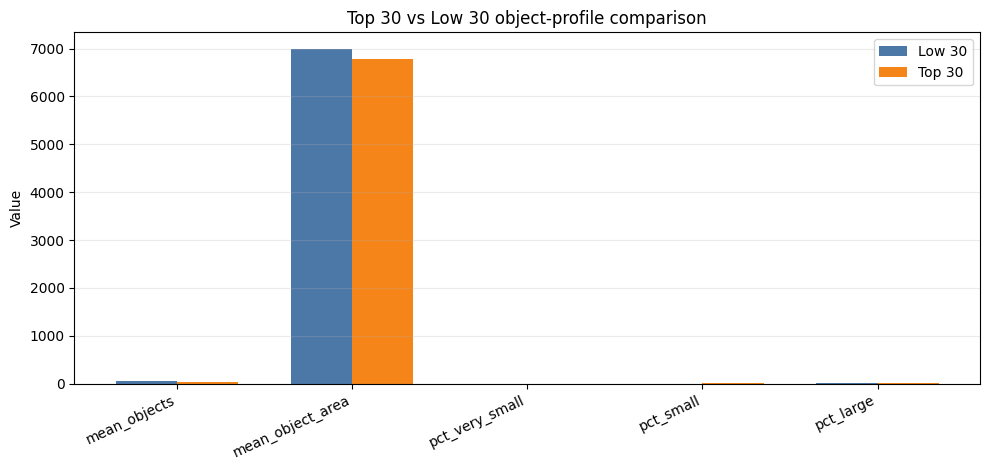


Interpretation helper:
- If the top tertile has more very_small/small objects and lower mean_object_area, that matches the low AP buckets.
- If its dominant domain is also a minority domain, then the difficulty score is probably clustering around a sparse or hard-to-detect subpopulation.
- If the top tertile is mostly one or two domains, that is a strong domain effect rather than a random score spread.


In [4]:
# Global AP context by object size. This explains why domains rich in tiny objects tend to look hard.
ap_by_bucket = pd.DataFrame([
    {'bucket': 'very_small', 'ap': eval_data.get('AP_very_small', np.nan)},
    {'bucket': 'small', 'ap': eval_data.get('AP_small', np.nan)},
    {'bucket': 'medium', 'ap': eval_data.get('AP_medium', np.nan)},
    {'bucket': 'large', 'ap': eval_data.get('AP_large', np.nan)},
])
print('Baseline AP by object size bucket:')
print(ap_by_bucket.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

top_tert = image_model_df[image_model_df['score_tertile'] == 'top_30'].copy()
top_domain = top_tert['domain'].value_counts().idxmax()
top_domain_share = top_tert['domain'].value_counts(normalize=True).iloc[0]
top_domain_rows = tert_domain_table[(tert_domain_table['score_tertile'] == 'top_30') & (tert_domain_table['domain'] == top_domain)]
top_domain_stats = top_domain_rows.iloc[0] if len(top_domain_rows) else None

print('\nTop tertile majority domain:', top_domain)
print('Share inside top tertile:', round(float(top_domain_share), 4))

if top_domain_stats is not None:
    print('Top-domain object profile inside top tertile:')
    print(top_domain_stats[['n_images', 'mean_score', 'mean_objects', 'mean_object_area', 'pct_very_small', 'pct_small', 'pct_medium', 'pct_large']].round(4).to_string())

# Compare top-tertile dominant domain against overall tertile averages.
top_tert_avg = tertile_object_summary.loc['top_30']
low_tert_avg = tertile_object_summary.loc['low_30']

print('\nHow the top tertile differs from the low tertile:')
comparison = pd.DataFrame([
    {'metric': 'mean_objects', 'top_30': top_tert_avg['mean_objects'], 'low_30': low_tert_avg['mean_objects']},
    {'metric': 'mean_object_area', 'top_30': top_tert_avg['mean_object_area'], 'low_30': low_tert_avg['mean_object_area']},
    {'metric': 'pct_very_small', 'top_30': top_tert_avg['pct_very_small'], 'low_30': low_tert_avg['pct_very_small']},
    {'metric': 'pct_small', 'top_30': top_tert_avg['pct_small'], 'low_30': low_tert_avg['pct_small']},
    {'metric': 'pct_large', 'top_30': top_tert_avg['pct_large'], 'low_30': low_tert_avg['pct_large']},
])
comparison['delta'] = comparison['top_30'] - comparison['low_30']
print(comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['low_30'], width=w, label='Low 30', color='#4c78a8')
ax.bar(x + w/2, comparison['top_30'], width=w, label='Top 30', color='#f58518')
ax.set_xticks(x)
ax.set_xticklabels(comparison['metric'], rotation=25, ha='right')
ax.set_ylabel('Value')
ax.set_title('Top 30 vs Low 30 object-profile comparison')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

print('\nInterpretation helper:')
print('- If the top tertile has more very_small/small objects and lower mean_object_area, that matches the low AP buckets.')
print('- If its dominant domain is also a minority domain, then the difficulty score is probably clustering around a sparse or hard-to-detect subpopulation.')
print('- If the top tertile is mostly one or two domains, that is a strong domain effect rather than a random score spread.')

## What this notebook tells you

- The score tertile split shows which domains dominate the low, mid, and top 30%.
- The object-size summary shows whether the top tertile is driven by small-object density or sparse scenes.
- The AP table gives the global baseline weakness by object size bucket.

If the top tertile is dominated by a minority domain and that domain has a higher share of very small or small objects, then the clustering is probably explained by a real model weakness on tiny targets rather than just noise in the scoring file.